In [41]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.utils.data import get_pkg_data_filename
import astropy.units as u
import pandas as pd
from astropy.table import Table

mpl.rcParams['figure.dpi']=800
plt.rcParams['font.family'] = "serif"
plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = "stix"

In [7]:

class spectrum1d(object):
    def __init__(self, wave, flux, error=None):
        #Could be np.asarray, but change fit_spectral_lines.py
        self.wave = np.float_(wave)
        self.flux = np.float_(flux)
        self.error = np.float_(error)

def calc_wavelength(header, pixels):
    if ('CTYPE1' in header.keys()) and (len(header['CTYPE1'])>1):
        if header['CTYPE1'] != 'LINEAR': 
            keep_going = input('Attempting to apply a linear solution to non-linear parameters. Continue anyways? (y), n ')
            if keep_going == 'n':
                sys.exit()
    else:
        print('WARNING: No solution type specified, assuming linear')
    CRVAL1 = header['CRVAL1']
    if 'CRPIX1' in header.keys():
        CRPIX1 = header['CRPIX1']
    else:
        CRPIX1 = 0
    if 'CD1_1' in header.keys():
        CD1_1 = header['CD1_1']
    elif 'CDELT1' in header.keys():
        CD1_1 = header['CDELT1']
    elif 'PC1_1' in header.keys():
        CD1_1 = header['PC1_1']
    else:
        sys.exit('Could not identify linear wavelength term (tried CD1_1, CDELT1, PC1_1)')
    
    wavelength = CRVAL1 + CD1_1*(pixels - CRPIX1)
    return wavelength

def make_1d_spec(ifile):
    ofile = fits.open(ifile)
    print(ofile)
    if 'sum_obj' in ifile or '_tel' in ifile or 'MMIRS' in ifile:
        hdr = ofile['FLUX'].header
        print(hdr)
        data = ofile['FLUX'].data
    if 'coadd' in ifile:
        hdr = ofile[1].header
        print(hdr)
        data_tup = ofile[1].data
        data = [],[],[],[],[]
        for i in range(len(data_tup)):
            data[0].append(data_tup[i][0])
            data[1].append(data_tup[i][1])
            data[2].append(data_tup[i][2])
            data[3].append(data_tup[i][3])
            data[4].append(data_tup[i][4])
        print(data[3])
        data = np.array(data)
    if 'sum_obj' not in ifile and '_tel' not in ifile and 'coadd' not in ifile and 'MMIRS' not in ifile:
        hdr = ofile[0].header
        print(hdr)
        data = ofile[0].data
    print(data.shape)
    if 'Bok' in ifile or 'untrim' in ifile or 'test' in ifile or 'GMOS' in ifile:
        #print(data[0,:].shape, data[0,:][0].shape)
        flux = data#[0,:]#[0]
    elif 'obj' in ifile or '_tel' in ifile or 'MMIRS' in ifile and 'Bok' not in ifile:
        flux = data #[0,:]
    elif 'LBT' in ifile:# or 'MMIRS' in ifile:
        flux = data#[0,:]
    elif '_B' in ifile or 'Binospec' in ifile and 'Bok' not in ifile:
        flux = data[0,:]
    elif 'coadd' in ifile:
        flux = data[2]
    else: #if 'untrim' not in ifile and 'Bok' not in ifile and '_B' not in ifile and 'obj' not in ifile and 'coadd' not in ifile and '_tel' not in ifile and 'MMIRS' not in ifile and 'test' not in ifile and 'LBT' not in ifile:
        flux = data[0,:][0]#[1]
        print('the all others case')
    #print(flux.shape)
   # flux = data
    if 'coadd' not in ifile:
        pix = np.arange(len(flux))+1
        #print(flux)
        wl = calc_wavelength(hdr, pix)
    if 'coadd' in ifile:
        wl = data[0]
        print(wl)
    spectrum = spectrum1d(wl, flux)
    return spectrum


def return_header(ifile):
    ofile = fits.open(ifile)
    print(ofile)
    if 'sum_obj' in ifile or '_tel' in ifile or 'MMIRS' in ifile:
        hdr = ofile['FLUX'].header
    if 'coadd' in ifile:
        hdr = ofile[1].header
    if 'sum_obj' not in ifile and '_tel' not in ifile and 'coadd' not in ifile and 'MMIRS' not in ifile:
        hdr = ofile[0].header
    return hdr


In [39]:
#23ufx
dir1 = '/mnt/nas/bok/bok/2024Apr12/reduced/'
ifile = 'SN2024ggi_test_blue.fits'

dir2 = '/mnt/nas/bok/bok/2024Apr13/reduced/'
ifile2 = 'SN2024ggi_test_blue.fits'

dir3 = '/mnt/nas/bok/bok/2024Apr14/reduced/'
ifile3 = 'SN2024ggi_test_blue.fits'

dir4='/home/jenivevepearson/Downloads/'
#ifile3 = 'pepsib.20240205.008.dxt.all'
ifile4 = 'SN2024ggi_20240412_redblu_125133.297.fits'

ofile=Table.read(dir3+ifile3)
print(ofile)

plt.ylim(0.5,1.5)
plt.xlim(4500,4700)
plt.ylabel('Flux')
plt.xlabel(r'Wavelength [$\mathrm{\AA}$]')
plt.plot(ofile['Arg'], ofile['Fun'])

#plt.savefig(dir3 + '23bch_PEPSI_Halpha_zoom.png', bbox_inches = 'tight')

In [71]:
dir1 = '/home/jenivevepearson/Desktop/Observing/24bch/SN2024bch/2024.0312/obj_abs_1D/'
ifile = 'SN2024bch_B.fits'

dir2 = '/home/jenivevepearson/Downloads/'
ifile2 = 'sn2024bch_20240317_redblu_120835.507.fits'
#dir2 = '/home/jenivevepearson/Desktop/Observing/23tsz/SN2023tsz/2023.1115/obj_abs_1D/'
#ifile2 = 'SN2023tsz_B.fits'

dir3 = '/home/jenivevepearson/Desktop/Observing/24bch/SN2024bch/2024.0405/obj_abs_1D/'
ifile3 = 'SN2024bch_B.fits'

#dir4 = '/home/jenivevepearson/Desktop/Observing/23rau/SN2023rau/2023.1020/obj_abs_1D/'
#ifile4 = 'SN2023rau_B.fits'

dir4 = '/home/jenivevepearson/Downloads/'
ifile4 = 'sn2024bch_20240408_redblu_064455.967.fits'

dir2 = '/home/jenivevepearson/Desktop/Observing/23ixf/SN2023ixf_HK/2024.0131/'
ifile2 = 'sum_obj-sky_slits_extr_corr.fits'

dir1 = '/home/jenivevepearson/Desktop/Observing/23ixf/SN2023ixf_zJ/2024.0131/'
ifile = 'sum_obj-sky_slits_extr_corr.fits'


dir3 = '/home/jenivevepearson/Desktop/Observing/23ixf/SN2023ixf_zJ/2023.1204/'
ifile3 = 'sum_obj-sky_slits_extr_corr.fits'

dir4 = '/home/jenivevepearson/Desktop/Observing/23ixf/SN2023ixf_HK/2023.1204/'
ifile4 = 'sum_obj-sky_slits_extr_corr.fits'

dir1 = '/home/jenivevepearson/Desktop/Observing/23ixf/ForJeonghee/'
ifile = 'SN2023ixf_MMT_MMIRS_20240131_zJ.fits'
ifile2 = 'SN2023ixf_MMT_MMIRS_20240131_HK.fits'
ifile3 = 'SN2023ixf_MMT_MMIRS_20231204_zJ.fits'
ifile4 = 'SN2023ixf_MMT_MMIRS_20231204_HK.fits'

dir5 = '/home/jenivevepearson/Downloads/'
ifile5 = 'SN2023ixf_HK_20231204_telcor.dat'

#23ufx
#dir1 = '/home/jenivevepearson/Downloads/'
#ifile = 'SN2023ufx_zJ_corr.fits'

dir2 = '/home/jenivevepearson/Downloads/'
ifile2 = 'coadd_1D_23ufx_telcorr.fits'

dir3 = '/home/jenivevepearson/Desktop/Observing/23ufx/new_202401/SN2023ufx_zJ/2023.1203/'
ifile3 = 'sum_obj-sky_slits_extr_corr.fits'

dir4 = '/home/jenivevepearson/Desktop/Observing/23ufx/new_202401/SN2023ufx_HK/2023.1203/'
ifile4 = 'sum_obj-sky_slits_extr_corr.fits'

In [24]:
#'/home/jenivevepearson/Desktop/Observing/23ufx/SN2023ufx_zJ/2023.1204/'

dir1 = '22joj/2023.0326/'
ifile = 'SN2022joj_B.fits'

dir2 = '/home/jenivevepearson/Downloads/'
ifile2 = 'SN2022joj_coadd_2023-01-25_248.fits'
#ifile3 = '2023.0326/obj_abs_1D/SN2022joj_B.fits'

In [63]:
ispec = make_1d_spec(dir1+ifile)
ispec.wave = ispec.wave#[~np.isnan(ispec.flux)]*10   #Binospec data are systematically of by ~10-15A
ispec.flux = ispec.flux#[~np.isnan(ispec.flux)]
print(ispec.wave)

#ispec = np.genfromtxt(dir1+ifile, unpack=True)
#ispec_wave = ispec[0]
#ispec_flux = ispec[1]


SIMPLE  =                    T /  Written by IDL:  Tue Mar 12 13:17:30 2024     BITPIX  =                  -32 /                                                NAXIS   =                    2 /                                                NAXIS1  =                 4166 /                                                NAXIS2  =                    4 /                                                EXTEND  =                    T / Extensions may be present                      BSCALE  =                    1 /           /                                    BZERO   =                    0 /           /                                    OBSERVAT= 'mmto'                           /                                    TELESCOP= 'mmt_f5_adc'                     /                                    ORIGIN  = 'MMT Binospec Camera'            /                                    INSTRUME= 'Binospec'                       /                                    CCDSUM  = '1 1'                         

In [64]:
#dir2=dir1

ispec2 = make_1d_spec(dir2+ifile2)
ispec2.wave = ispec2.wave#*10   #Binospec data are systematically of by ~10-15A
ispec2.flux = ispec2.flux
print(ispec2.flux)

#ispec2 = np.genfromtxt(dir2+ifile2, delimiter=',', unpack=True)
#ispec2_wave = ispec2[0]
#ispec2_flux = ispec2[1]
#print(ispec2_wave)

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    3 / Number of axes                                 NAXIS1  =                 3262 / Axis length                                    NAXIS2  =                    1 / Axis length                                    NAXIS3  =                    4 / Axis length                                    EXTEND  =                    F / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2034-03-18T18:54:09' / Date FITS file was generated                  IRAF-TLM= '2034-03-18T18:54:09' / Time of last modification                     OBJECT  = 'sn2024bch'          / Name of the object observed                    DATADICV= 'LCOGT-FITS-SPECTRO.DIC-0.0.5' / Version number of the data dictionaryHDRVER  = 'LCOGT-HDR-2.0.1'    / Version

In [72]:
#dir3=dir1
ispec3 = make_1d_spec(dir3+ifile3)
ispec3.wave = ispec3.wave#[~np.isnan(ispec3.flux)]*10   #Binospec data are systematically of by ~10-15A
ispec3.flux = ispec3.flux#[~np.isnan(ispec3.flux)]
print(ispec3.flux)
print(min(ispec3.wave), max(ispec3.wave))

SIMPLE  =                    T /  Written by IDL:  Fri Apr  5 20:54:23 2024     BITPIX  =                  -32 /                                                NAXIS   =                    2 /                                                NAXIS1  =                 4166 /                                                NAXIS2  =                    4 /                                                EXTEND  =                    T / Extensions may be present                      BSCALE  =                    1 /           /                                    BZERO   =                    0 /           /                                    OBSERVAT= 'mmto'                           /                                    TELESCOP= 'mmt_f5_adc'                     /                                    ORIGIN  = 'MMT Binospec Camera'            /                                    INSTRUME= 'Binospec'                       /                                    CCDSUM  = '1 1'                         

In [66]:
#dir4=dir1
ispec4 = make_1d_spec(dir4+ifile4)
ispec4.wave = ispec4.wave#*10   #Binospec data are systematically of by ~10-15A
ispec4.flux = ispec4.flux
print(ispec4.wave)

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    3 / Number of axes                                 NAXIS1  =                 2842 / Axis length                                    NAXIS2  =                    1 / Axis length                                    NAXIS3  =                    4 / Axis length                                    EXTEND  =                    F / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2024-04-10T23:56:20' / Date FITS file was generated                  IRAF-TLM= '2024-04-10T23:56:20' / Time of last modification                     OBJECT  = 'sn2024bch'          / Name of the object observed                    DATADICV= 'LCOGT-FITS-SPECTRO.DIC-0.0.5' / Version number of the data dictionaryHDRVER  = 'LCOGT-HDR-2.0.1'    / Version

In [87]:
#ispec5 = make_1d_spec(dir5+ifile5)
#ispec5.wave = ispec5.wave#*10   #Binospec data are systematically of by ~10-15A
#ispec5.flux = ispec5.flux
#print(ispec5.wave)

ispec5 = Table.read(dir5+ifile5, format='ascii')
print(ispec5)
ispec5_wave = ispec5['col1']
ispec5_flux = ispec5['col2']
#print(ispec5_wave)

  col1      col2        col3   
------- ----------- -----------
1249.75         nan         nan
 1250.4 1.20611e-12 1.00956e-16
1251.05 1.27046e-12 1.03982e-16
 1251.7 1.20941e-12  9.9306e-17
1252.35  1.3393e-12 1.11594e-16
 1253.0 1.24962e-12 1.00791e-16
1253.65 1.19963e-12 9.34258e-17
 1254.3 1.29544e-12 1.06222e-16
1254.95 1.25584e-12 9.88232e-17
 1255.6 1.20497e-12 9.80227e-17
    ...         ...         ...
 2359.3 1.02841e-12 1.35789e-15
2359.95 1.03236e-12 1.34773e-15
 2360.6 1.00085e-12 1.21119e-15
2361.25 8.77257e-13 1.04218e-15
 2361.9 9.60084e-13 1.27242e-15
2362.55  9.8219e-13 1.31023e-15
 2363.2 1.07244e-12 1.43908e-15
2363.85 1.20742e-12 1.59787e-15
 2364.5 1.06986e-12 1.43978e-15
2365.15 9.67718e-13 1.41109e-15
 2365.8 9.13182e-13 1.15044e-15
Length = 1718 rows


In [110]:
from astropy.convolution import convolve, Box1DKernel

def smoothline(x, y, offset, c, zo=1, label='no', smooth_by=50):
    # smooth the data
    box_kernel = Box1DKernel(smooth_by)
    y_s = convolve(y, box_kernel)
    if label == 'no':
        plt.plot(x, y_s+offset, color=c, linewidth=1.5, zorder=zo)
    if label != 'no':
        plt.plot(x, y_s+offset, color=c, linewidth=1.5, zorder=zo, label=label)

print(np.isnan(ispec.flux))

def printnans(spec_wave, spec_flux, name, color='b', offset=0):
    lab = 0
    for i in range(len(spec_flux)):
        if np.isnan(spec_flux[i])==True:
            plt.scatter(spec_wave[i], offset, color=color) 
            if lab==0:
                plt.scatter(spec_wave[i], offset, label=name, color=color) 
                lab+=1
    return
#printnans(ispec5.wave, ispec5.flux, '20caa Feb 2021', color='pink', offset=0.0)
printnans(ispec3.wave, ispec3.flux, '23ixf Jun', color='r', offset=0.05)
printnans(ispec4.wave, ispec4.flux, '23rau Oct', color='g', offset=0.1)
printnans(ispec2.wave+200, ispec2.flux, '23tsz Nov', color='springgreen', offset=0.15)
printnans(ispec.wave, ispec.flux, '23zcu Jan', offset=0.2)
plt.legend()
plt.title('Position of nan values in Binospec data')
plt.savefig('/home/jenivevepearson/Downloads/' + 'nan_positions_binospec.png', bbox_inches = 'tight')
#print((ispec3.wave),(ispec3.flux[~np.isnan(ispec3.flux)]))

<ipython-input-79-ad7500bd1ffb>:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux)-1, 'k',label='24bch; FLOYDS 4/8', color=cmap(0.85), zorder=4)


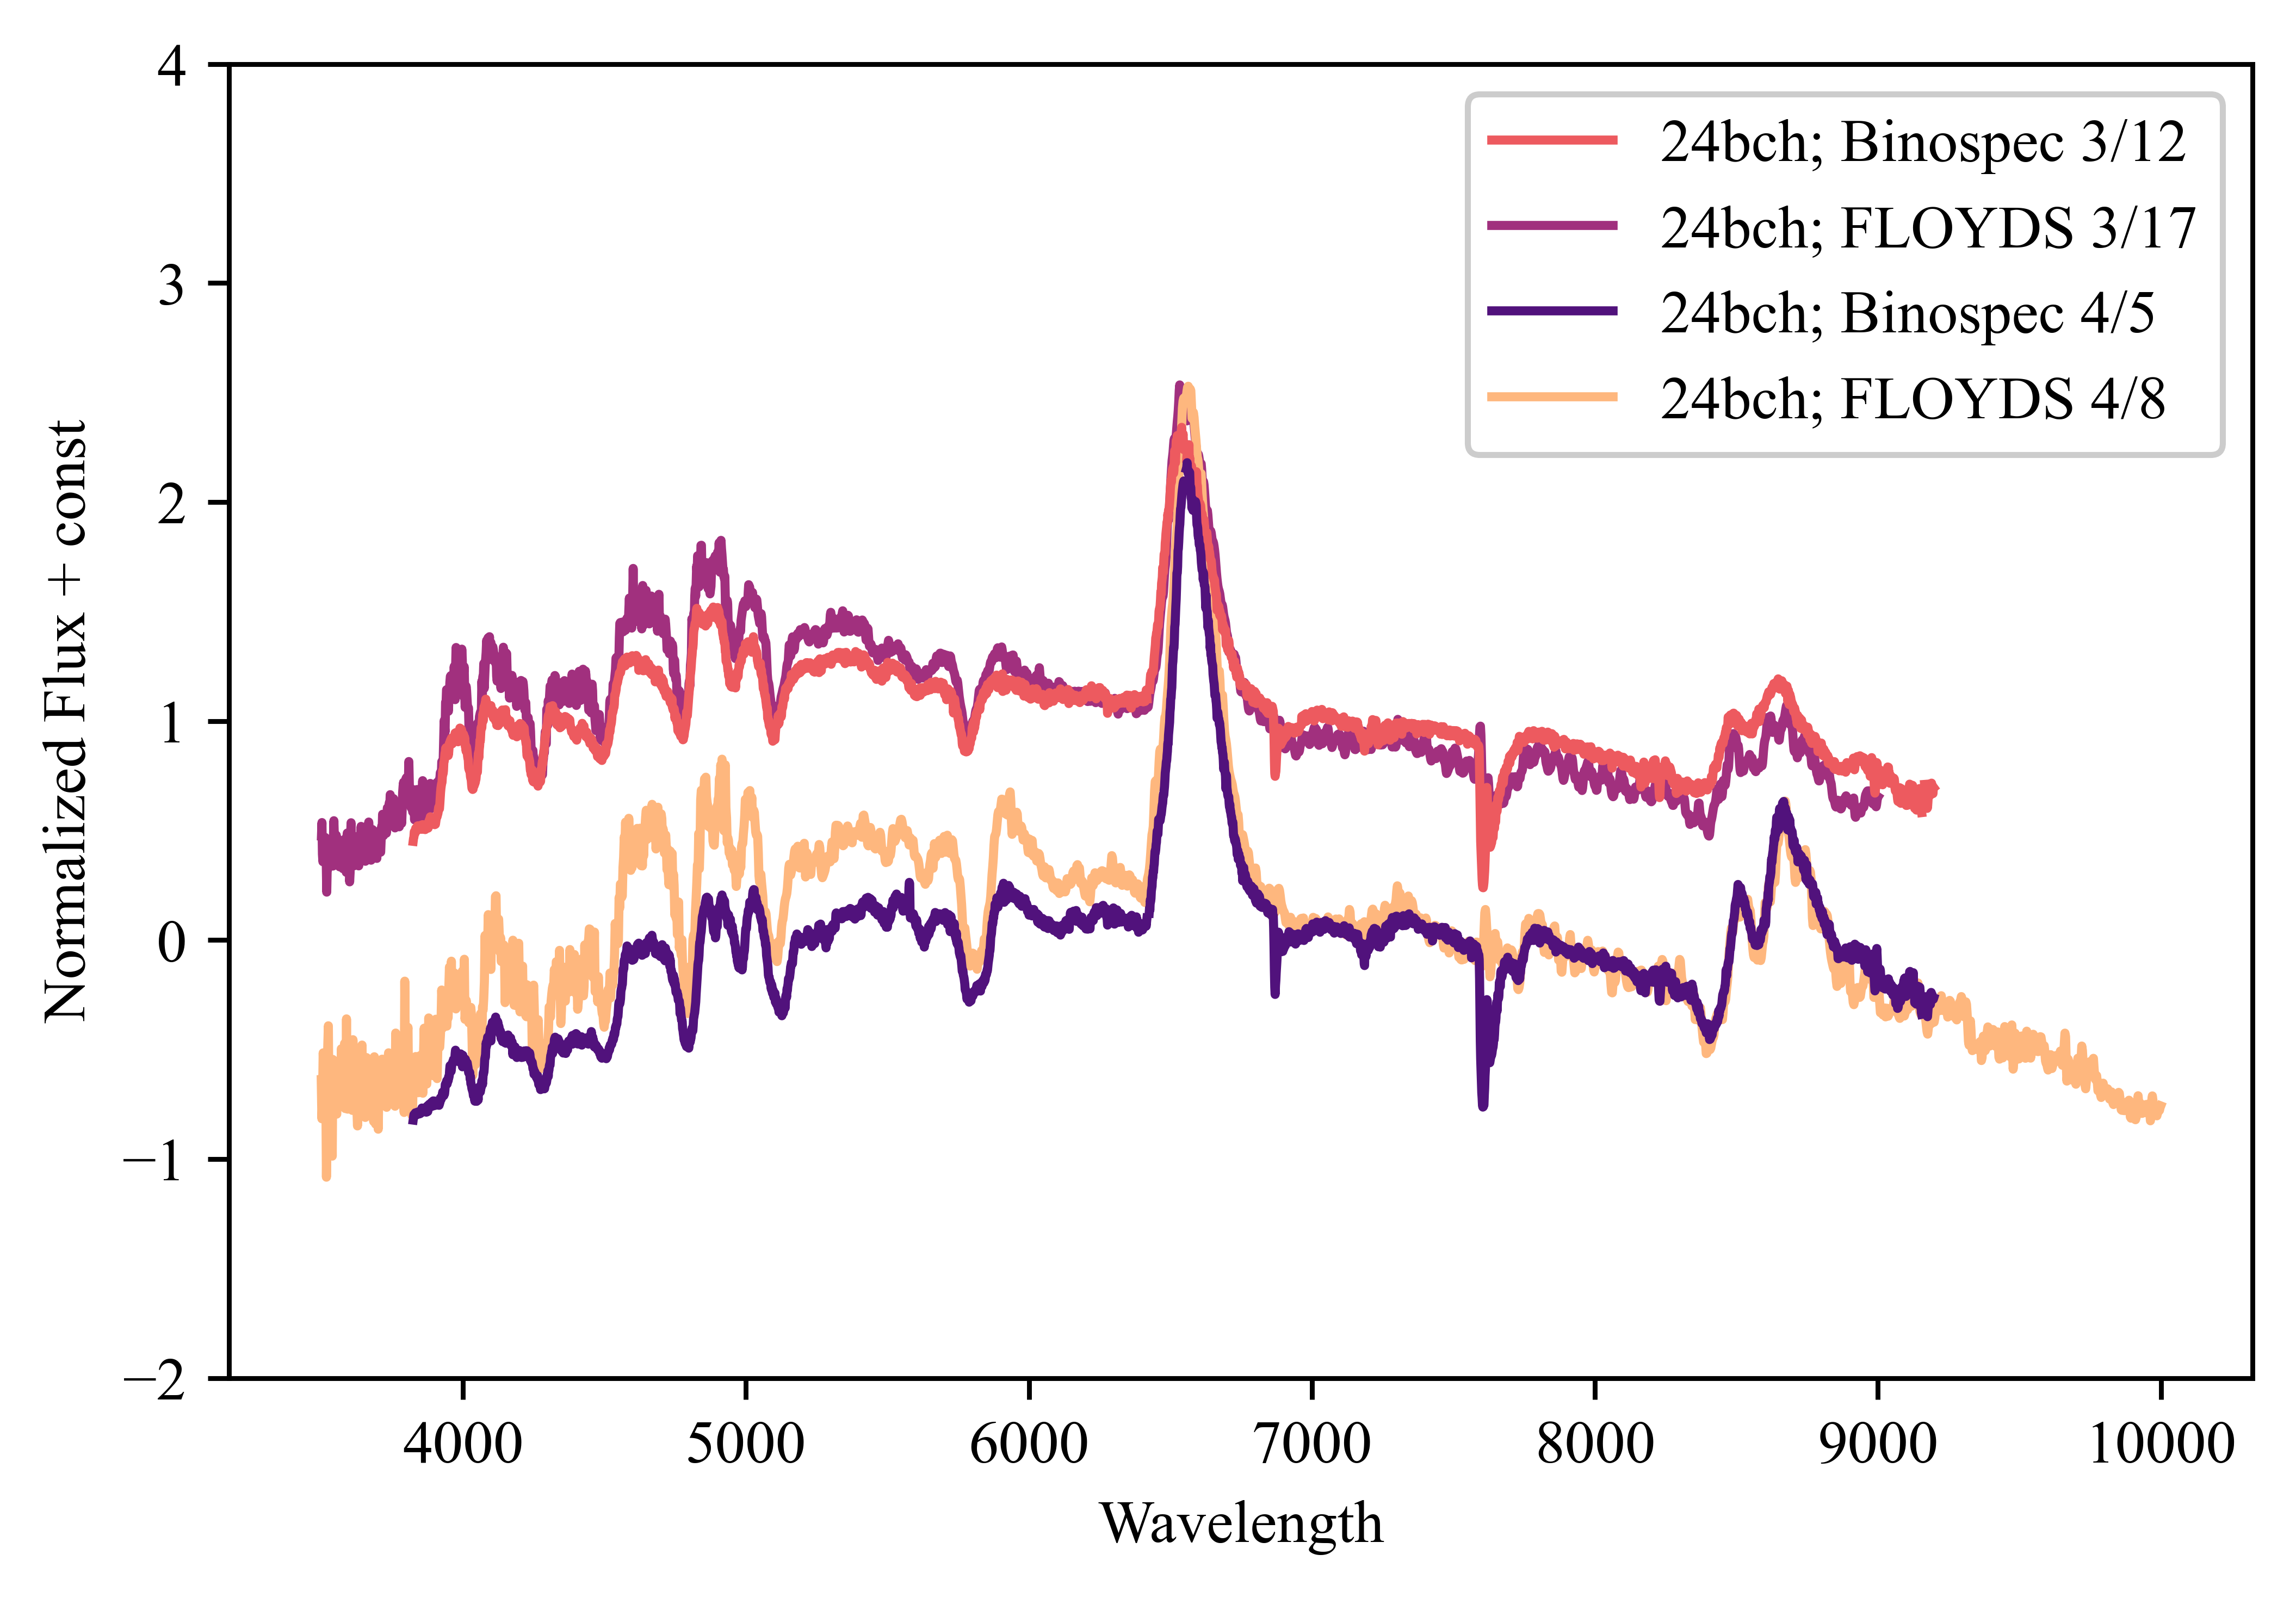

In [79]:
plt.ylim(-2,4)
#plt.xlim(6000, 7000)

cmap = plt.get_cmap('magma')
plt.set_cmap(cmap)
print(cmap)



plt.plot(ispec.wave,ispec.flux/np.nanmedian(ispec.flux),label='24bch; Binospec 3/12', zorder=5, color=cmap(0.65))
#plt.plot(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux),label='SN2023zcu; FLOYDS 12/15')
plt.plot(ispec2.wave,ispec2.flux/np.nanmedian(ispec2.flux), label='24bch; FLOYDS 3/17', zorder=4, color=cmap(0.45))

plt.plot(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux)-1,label='24bch; Binospec 4/5', zorder=5, color=cmap(0.25))
plt.plot(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux)-1, 'k',label='24bch; FLOYDS 4/8', color=cmap(0.85), zorder=4)

#plt.plot(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux),label='SN2023ixf; Bok 03/03/2024', zorder=5, color='red')
#plt.plot(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux)+0.7,'r',label='SN2023ufx; MMIRS zJ 12/3, new', zorder=5)


#plt.plot(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux), label='SN2023ixf; MMIRS HK 2023-12-04')
#smoothline(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux), 0, 'r',smooth_by=20, label='SN2023tsz; Binospec 1/10/24')

#plt.plot(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux)+5.5,label='SN2023ixf; MMIRS zJ 2023-12-04 auto', zorder=1)
#plt.plot(ispec2.wave,ispec2.flux/np.nanmedian(ispec2.flux),label='SN2023ixf; MMIRS HK 2023-01-31')
#plt.plot(ispec5_wave,ispec5_flux/np.nanmedian(ispec5_flux), 'k',label='SN2023ixf; MMIRS HK 2023-12-04 corrected')

#plt.plot(ispec.wave,ispec.flux/np.nanmedian(ispec.flux)+0.5,label='SN2023ixf; MMIRS zJ 2023-01-31', zorder=5)

#smoothline(ispec.wave,ispec.flux/np.nanmedian(ispec.flux), 0, 'b',smooth_by=50, label='SN2022joj; 324 days')
#smoothline(ispec2.wave,ispec2.flux/np.nanmedian(ispec2.flux), 0, 'g',smooth_by=20,label='SN2023ufx; MMIRS HK 2023-12-03 new')
#smoothline(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux)+0.6, 0, 'r',smooth_by=20, label='SN2023ufx; MMIRS zJ 2023-12-03 new')

#print((ispec2.wave))


plt.ylabel('Normalized Flux + const')
plt.xlabel('Wavelength')
plt.legend(framealpha=1, loc='upper right')
#plt.savefig(dir4 + '24ggi_BokBC_20240412_20240414.png', bbox_inches = 'tight')
plt.savefig('/home/jenivevepearson/Desktop/Observing/24bch/SN2024bch/'+ '24bch_Binospec_autored.png', bbox_inches = 'tight')
#plt.savefig(dir5 + '23ixf_MMT_MMIRS_HK_20231204_corr.png', bbox_inches = 'tight')

In [49]:
# add lines to file so we know what's what
def linelist(sntype):
    if sntype=='II' or sntype==2:
        ir_elements = [
            Element('H', [10941, 12822, 18756, 21661], '-', 'C0', row=0),
            Element('He', [10830, 20581],'-', 'C1', row=1),
            #Element('Ca II', [8498, 8542, 8662], '--', 'C4', row=2)
        ]
    if sntype=='I' or sntype==1:
        ir_elements = [
            #Element('Ca II', [8498, 8542, 8662], '--', 'C4', row=0),
            Element('Mg II', [9227, 10092, 10927, 16787, 21569], '--', 'gold', row=1)
        ]
    return

def Element(name, lines, style, color, row=1, group=False):
    locat = start+(row*spacer)
    plt.vlines(lines, -2, 10, linestyle=style, color=color,  alpha=0.6)
    
    if group==True:
        lines_g = pretty_labels(lines)     
    else: 
        lines_g=lines
    for i in range(len(lines_g)):
        if lines_g[i]>=20000. and lines_g[i]<=25000.:
            plt.text(lines_g[i], locat, name, ha='center', color=color)
    return

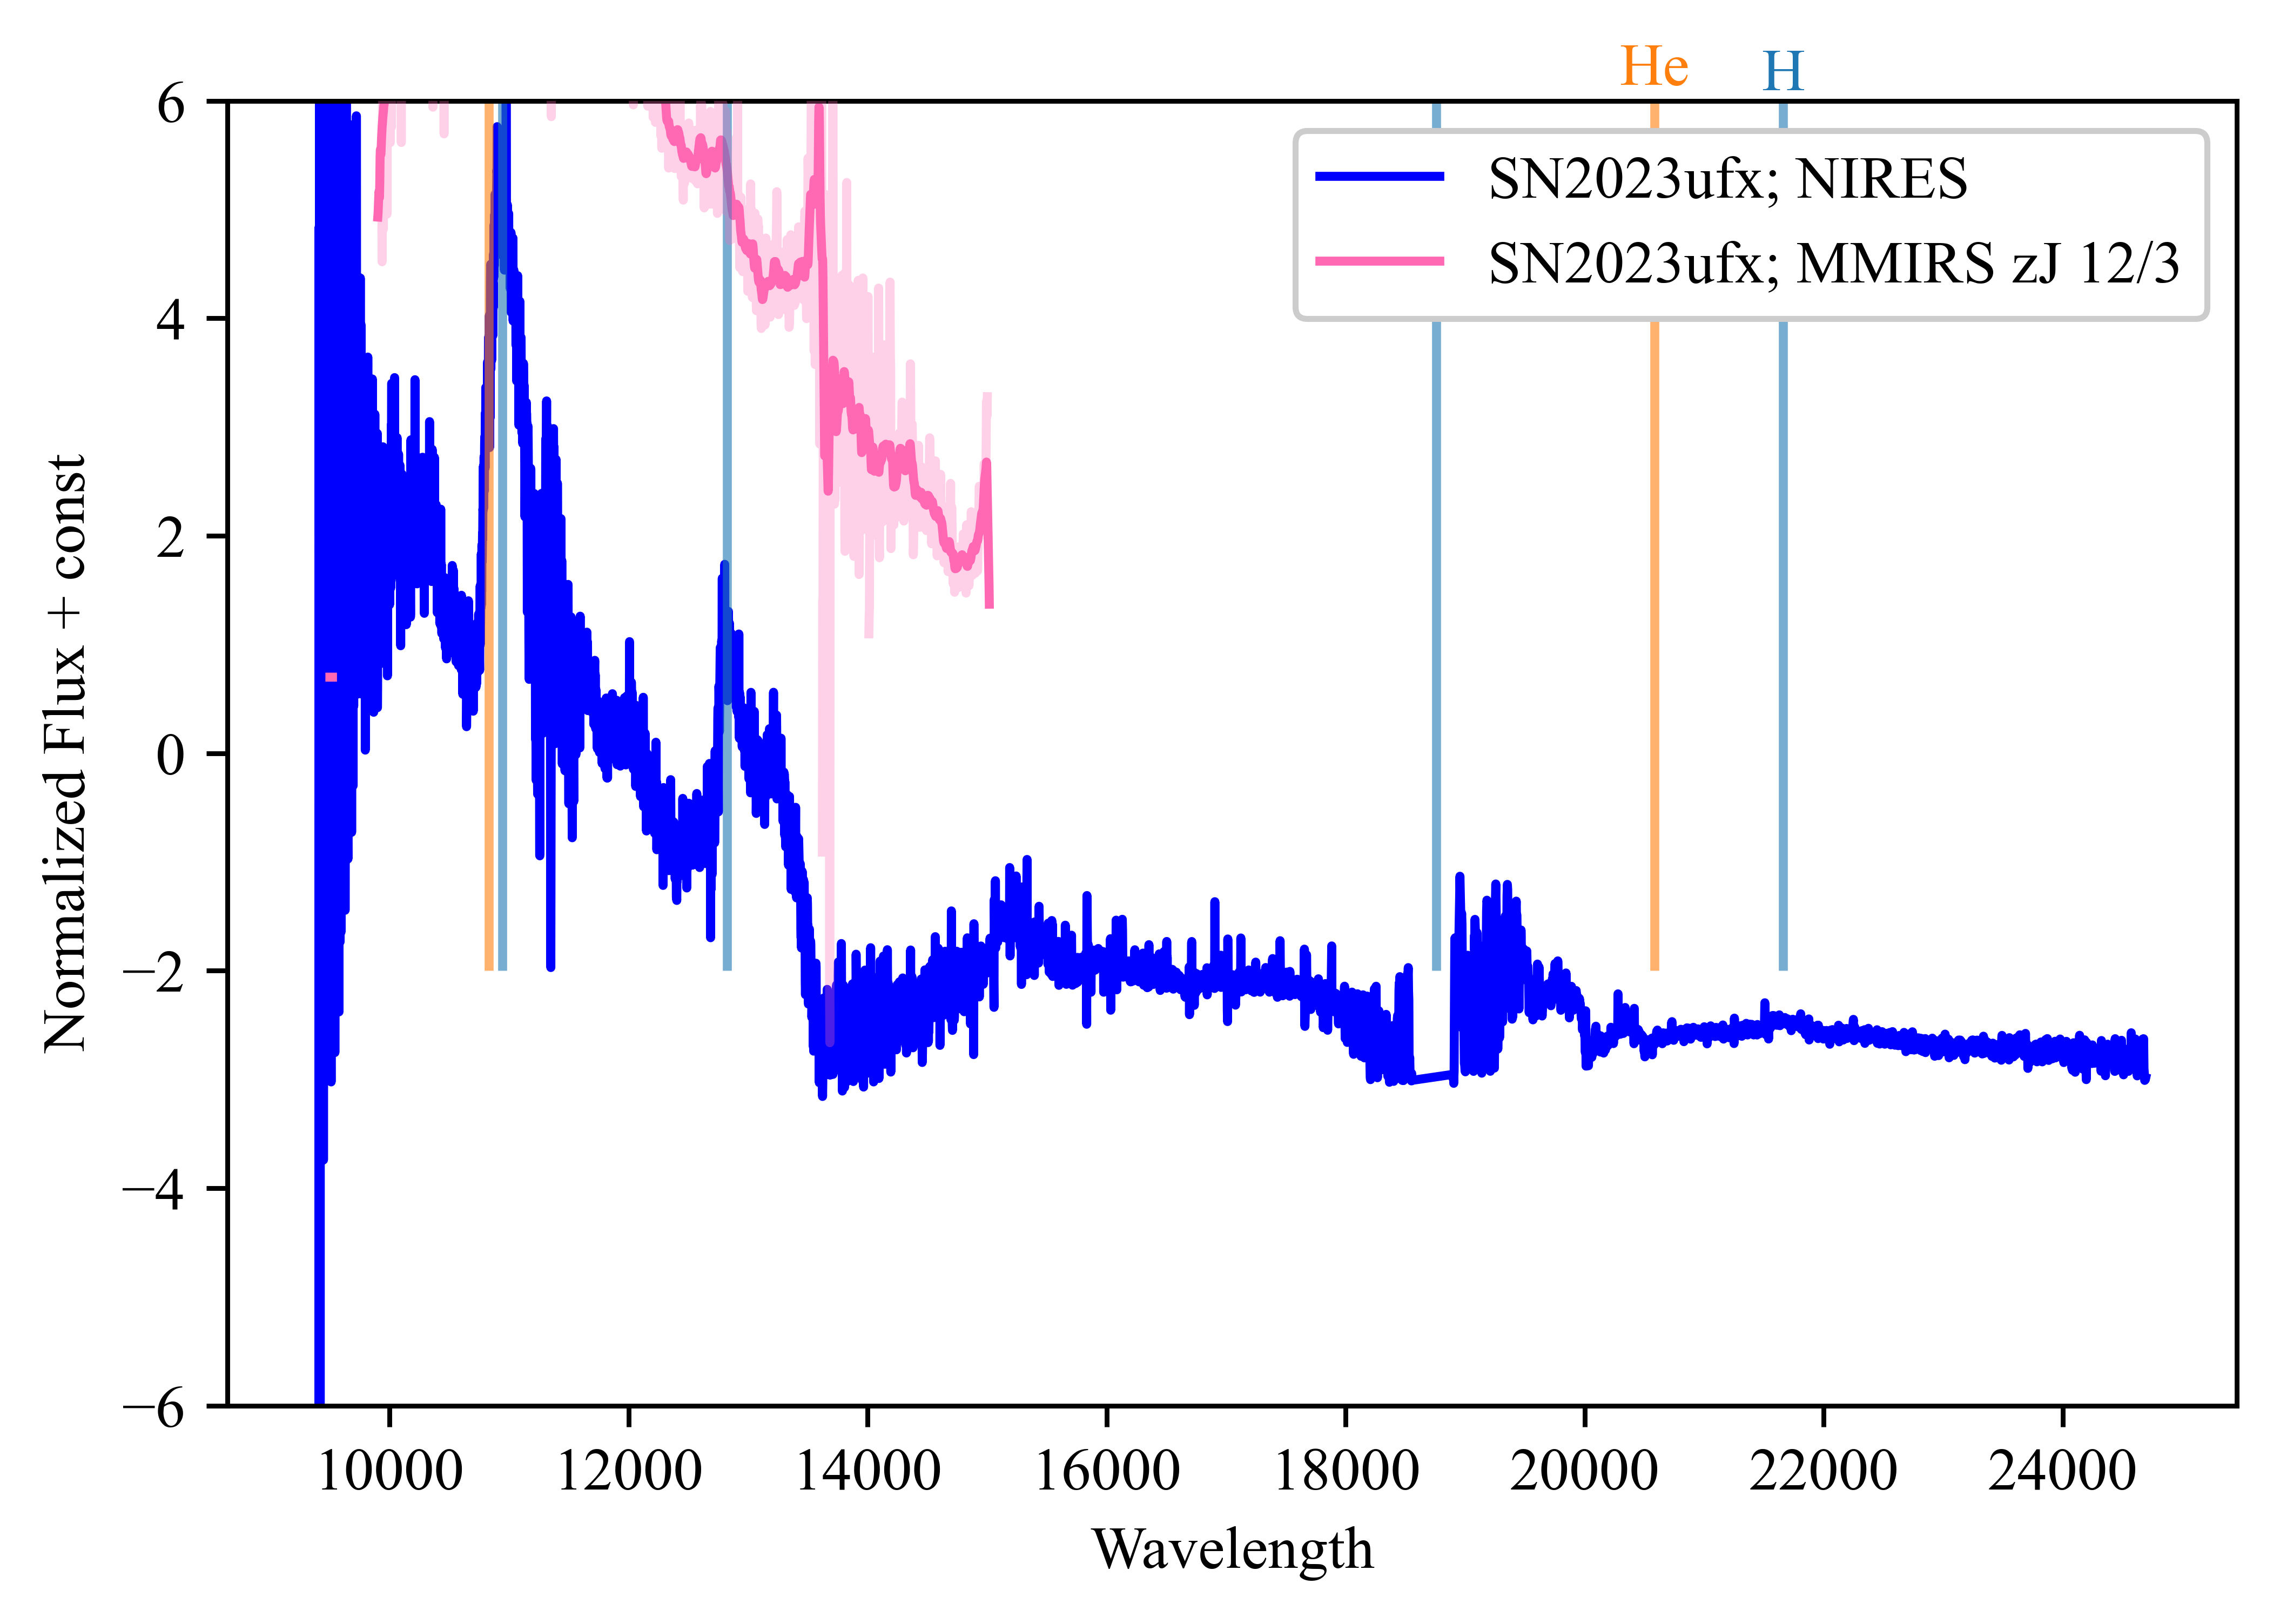

In [180]:
start=6.1
spacer=0.05
plt.ylim(-6.0, start-0.1)
#plt.xlim(20000, 22500)

#plt.plot(ispec.wave,ispec.flux/np.nanmedian(ispec.flux),'purple',label='SN2023ixf; MMIRS zJ 2023-12-04', zorder=5)
plt.plot(ispec2.wave,ispec2.flux/np.nanmedian(ispec2.flux)-3, 'blue',label='SN2023ufx; NIRES', zorder=1)
#plt.plot(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux), 'purple', alpha=0.3, zorder=5)
#smoothline(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux), 0, 'purple',smooth_by=20, label='SN2023ufx; MMIRS HK 12/3')
plt.plot(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux)*5+0.7, 'hotpink', alpha=0.3, zorder=5)
smoothline(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux)*5, 0.7, 'hotpink',smooth_by=20, label='SN2023ufx; MMIRS zJ 12/3')

linelist(2)

plt.ylabel('Normalized Flux + const')
plt.xlabel('Wavelength')
plt.legend(framealpha=1)
#plt.savefig(dir3 + '23ufx_MMTMMIRS_lines_labeled.png', bbox_inches = 'tight')


In [8]:
#put it in velocity space
halpha_wave = 6563
pbeta_wave = 12822
z_sn = 0.000804
ispec.vel = ((ispec.wave*(1-z_sn)-halpha_wave)/halpha_wave)*3e5
ispec2.vel = ((ispec2.wave*(1-z_sn)-halpha_wave)/halpha_wave)*3e5
ispec3.vel = ((ispec3.wave*(1-z_sn)-pbeta_wave)/pbeta_wave)*3e5

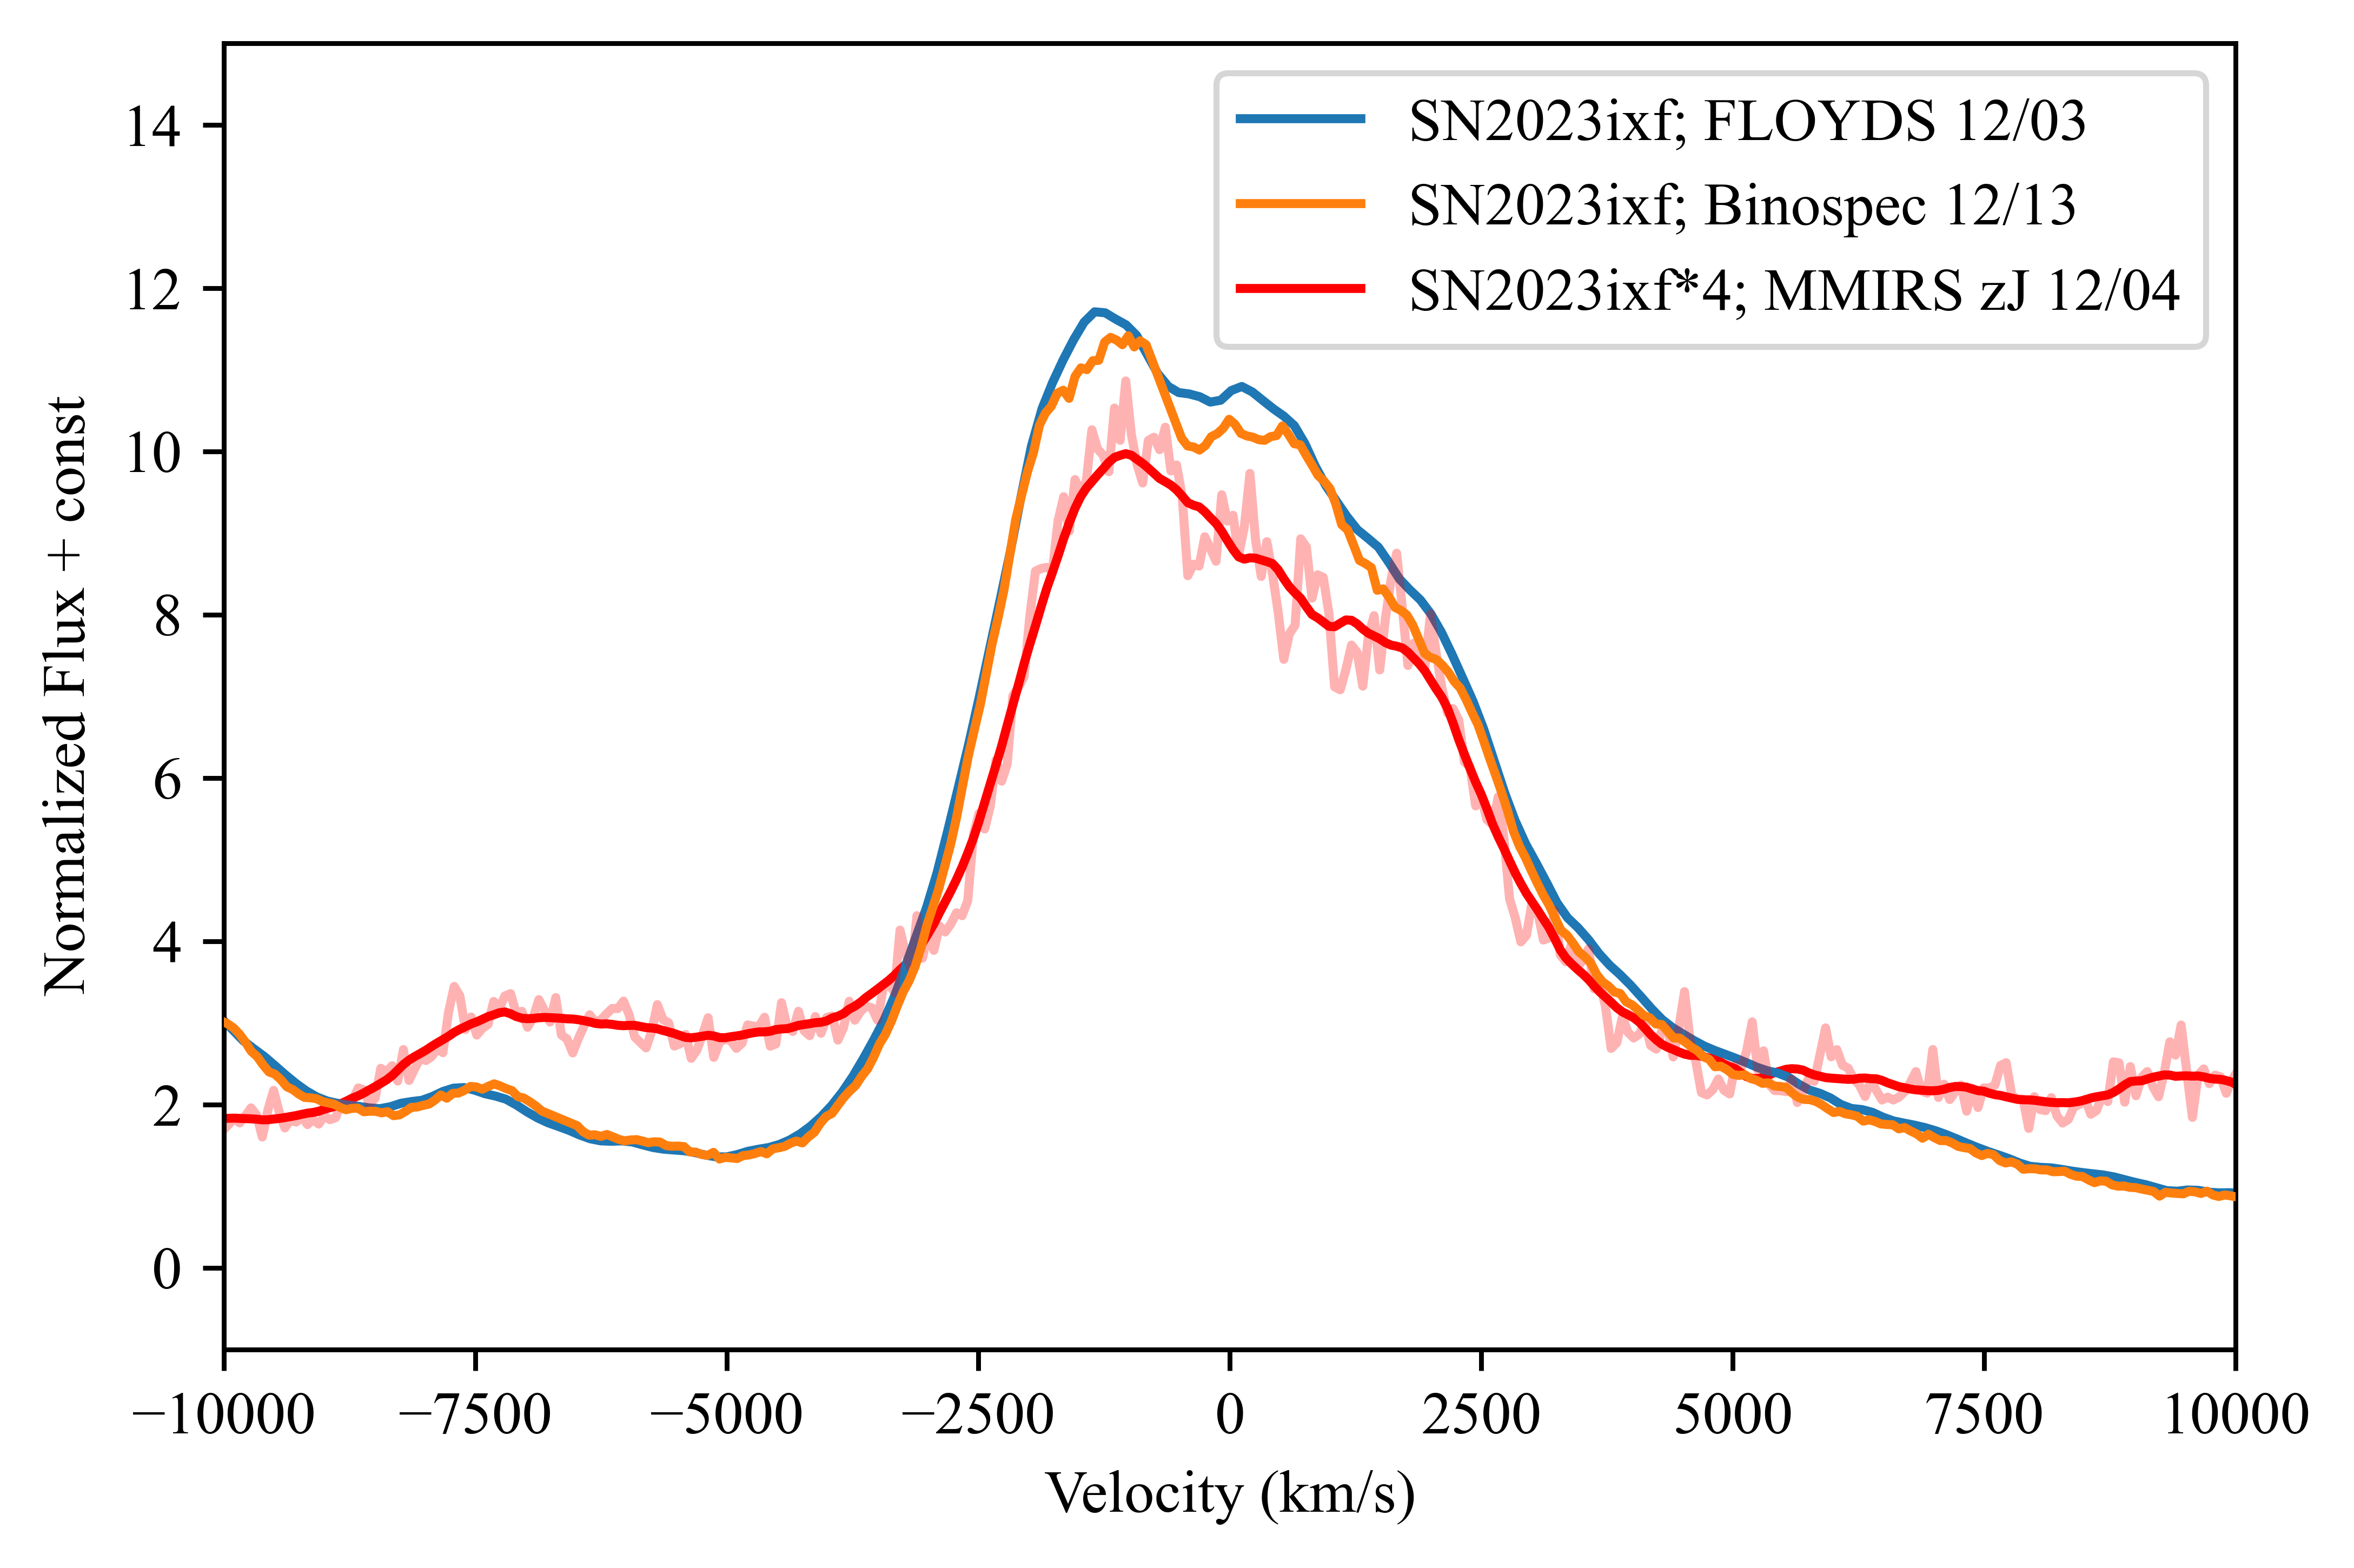

In [14]:
plt.ylim(-1, 15)
plt.xlim(-10000, 10000)

plt.plot(ispec2.vel,ispec2.flux/np.nanmedian(ispec2.flux), label='SN2023ixf; FLOYDS 12/03')


plt.plot(ispec.vel,ispec.flux/np.nanmedian(ispec.flux),label='SN2023ixf; Binospec 12/13', zorder=5)
#plt.plot(ispec3.wave,ispec3.flux/np.nanmedian(ispec3.flux),'r', alpha=0.3,label='SN2023ufx; MMIRS zJ 12/3')
#plt.plot(ispec4.wave,ispec4.flux/np.nanmedian(ispec4.flux), 'b',label='telluric')


plt.plot(ispec3.vel,(ispec3.flux/np.nanmedian(ispec3.flux))*4-1, 'r', alpha=0.3)
#plt.plot(ispec2.wave,ispec2.flux/np.nanmedian(ispec2.flux)-1.4,label='SN2023ixf; MMIRS HK 2023-12-04')
#plt.plot(ispec2_wave,ispec2_flux/np.nanmedian(ispec2_flux), 'grey',label='SN2022xxf; Keck NIRES 2023-04-10')


#smoothline(ispec.wave,ispec.flux/np.nanmedian(ispec.flux), 0, 'b',smooth_by=50, label='SN2022joj; 324 days')
#smoothline(ispec2.wave,ispec2.flux/np.nanmedian(ispec2.flux), 0, 'g',smooth_by=20,label='SN2023ufx; MMIRS HK 2023-12-03 new')
smoothline(ispec3.vel,(ispec3.flux/np.nanmedian(ispec3.flux))*4-1, 0, 'r',smooth_by=20, label='SN2023ixf*4; MMIRS zJ 12/04')

#print((ispec2.wave))
plt.ylabel('Normalized Flux + const')
plt.xlabel('Velocity (km/s)')
plt.legend()
plt.savefig(dir1 + '23ixf_compare_H_vel_122023.png', bbox_inches = 'tight')
#plt.savefig(dir2 + '23ufx_MMIRS_tellurics.png', bbox_inches = 'tight')

In [ ]:
for i in range(len(ispec2.wave)):
    if ispec2.flux[i] != 0:
        print(ispec2.wave[i])

plt.xlim(6000, 6600)
plt.plot(ispec3_wave,ispec3_flux,label='SN2022pul BAADE; 2023-06-24')
plt.plot(ispec.wave,ispec.flux,label='SN2022pul; 2023-06-23')
plt.plot(ispec2_wave,ispec2_flux,label='SN2022pul SOAR; 2023-06-04')
print((ispec.wave))
plt.ylabel('Flux')
plt.xlabel('Wavelength')
plt.legend()
plt.savefig('ForSaurabh/SN2022pul/Bino062322_22pul_zoom.png', bbox_inches = 'tight')

# Edit the fits file

In [61]:
from astropy.io import fits, ascii
from astropy.utils.data import get_pkg_data_filename

fits_file = get_pkg_data_filename(dir0+file1)
fits.setval(fits_file, 'EXPTIME', value='2400.0')

# Make text file and pretty picture to send with spectra zip file

In [28]:
from astropy.table import Table
from astropy.time import Time
import re
import glob

dir0 = '/home/jenivevepearson/Downloads/SN2024pxl_AZdata/'

files_fits = glob.glob(dir0+'*.fits')
print(files_fits)

#file1 = 'SN2023zcu-2023-12-09-GN-GMOS-B480_mnFMAUy.fits'
#file2 = 'SN2023zcu_Bino_20231215.fits'
#file3 = 'SN2023zcu_Bino_20240114.fits'
#file4 = 'SN2023zcu_Bino_20240302.fits'
#file5 = 'SN2023zcu_BokBC_20231214_clean.fits'
#file6 = 'SN2023zcu_BokBC_20240214.fits'

sn_name = 'SN2024pxl'

#files = [file1, file2, file5, file3, file6, file4]
spec_pic = [],[],[]
spec_info = Table(names=['filename', 'MJD', 'inst', 'tele', 'slit ["]', 'exp', 'wave'], dtype=[str, str, str, str, str, str, str])
for i in files_fits:
    print(i)
    hdr = return_header(i)
    
    if 'MJD' in hdr:
        mjd = hdr['MJD']
    elif 'MJD-OBS' in hdr:
        mjd = hdr['MJD-OBS']
    elif 'OBSTIME' in hdr:
        mjd = Time(hdr['OBSTIME'], format='isot', scale='utc').mjd
    elif 'UTC-OBS' in hdr and 'DATE-OBS' in hdr:
        mjd = Time(hdr['DATE-OBS']+'T'+hdr['UTC-OBS'], format='isot', scale='utc').mjd
    else:
        print('MJD not found')
        mjd = '0.0'
    
    if 'INSTRUME' in hdr:
        if len(re.sub("\d", "", hdr['INSTRUME']))==2: 
            inst = 'FLOYDS'
        else:
            inst = hdr['INSTRUME']
    else:
        inst = i
        print('Instrument not found, using filename. Please edit')
    
    if 'TELESCOP' in hdr:
        tele = hdr['TELESCOP']
    else:
        tele = i
        print('Telescope not found, using filename. Please edit')
    
    if 'bok' in tele or 'Bok' in tele:
        slit = '1.5'
        exptime = str(hdr['EXPTIME'])+'xnum'
    else:
        slit = '1.0'
        exptime = str(hdr['EXPTIME'])
        print('Assuming 1 arcsec slit width, make sure to check this')
    
    
    spec = make_1d_spec(i)
    spec.wave = spec.wave
    spec.flux = spec.flux
    spec_pic[0].append(spec.wave)
    spec_pic[1].append(spec.flux)
    spec_pic[2].append(str(mjd))
    
    factor=1
    if round(min(spec.wave)) < 1000:
        print('Assuming nm')
        factor = 10
    
    filename = i.replace(dir0, '')
    print([filename, str(mjd), inst, tele, slit, exptime, str(round(min(spec.wave)))+'-'+str(round(max(spec.wave)))])

    spec_info.add_row([filename, str(round(mjd,3)), inst, tele, slit, exptime,
                       str(round(min(spec.wave))*factor)+'-'+str(round(max(spec.wave))*factor)])

['/home/jenivevepearson/Downloads/SN2024pxl_AZdata/SN2024pxl_MMT_Bino_20240831.fits', '/home/jenivevepearson/Downloads/SN2024pxl_AZdata/SN2024pxl_MMT_Bino_20240812.fits']
/home/jenivevepearson/Downloads/SN2024pxl_AZdata/SN2024pxl_MMT_Bino_20240831.fits
Assuming 1 arcsec slit width, make sure to check this
SIMPLE  =                    T /  Written by IDL:  Tue Sep  3 15:20:22 2024     BITPIX  =                  -32 /                                                NAXIS   =                    2 /                                                NAXIS1  =                 3937 /                                                NAXIS2  =                    4 /                                                EXTEND  =                    T / Extensions may be present                      BSCALE  =                    1 /           /                                    BZERO   =                    0 /           /                                    OBSERVAT= 'mmto'                           /         

In [29]:
#if you have any text files you need to plot as well
from astropy.io import ascii
txt_file=False
files_txt = ['Kecklris_20240831_2024pxl.spec', 'SN2024pxl_MMT_Bino_20240930_cleaned.txt']
files_txt_mjd = [60553.235, 60583.086]
j=0
if txt_file:
    for i in files_txt:
        spec = ascii.read(dir0+i)
        spec_wave = spec['col1']
        spec_flux = spec['col2']
        spec_pic[0].append(spec_wave)
        spec_pic[1].append(spec_flux)
        spec_pic[2].append(str(files_txt_mjd[j]))
        j+=1

In [43]:
print(min(spec_pic[0][2]), max(spec_pic[0][2]))

3138.8232 10210.0


In [30]:
spec_info_sorted = spec_info.sort('MJD')
print(spec_info)
file = open(dir0 + f'{sn_name}_AZ_spectra_info.txt', 'a')
spec_info.write(file, format='ascii.fixed_width_two_line')
file.close()

            filename                MJD      inst   ...  exp      wave  
-------------------------------- --------- -------- ... ------ ---------
SN2024pxl_MMT_Bino_20240812.fits 60534.255 Binospec ... 1800.0 4318-9198
SN2024pxl_MMT_Bino_20240831.fits 60553.162 Binospec ... 1800.0 4120-9198


In [31]:
print(spec_info['tele'], spec_info['inst'])
times = Time((spec_pic[2]), format='mjd')
times.isot



   tele   
----------
mmt_f5_adc
mmt_f5_adc   inst  
--------
Binospec
Binospec


array(['2024-08-31T03:52:35.328', '2024-08-12T06:07:32.736',
       '2024-08-31T05:38:24.000', '2024-09-30T02:03:50.400'], dtype='<U23')

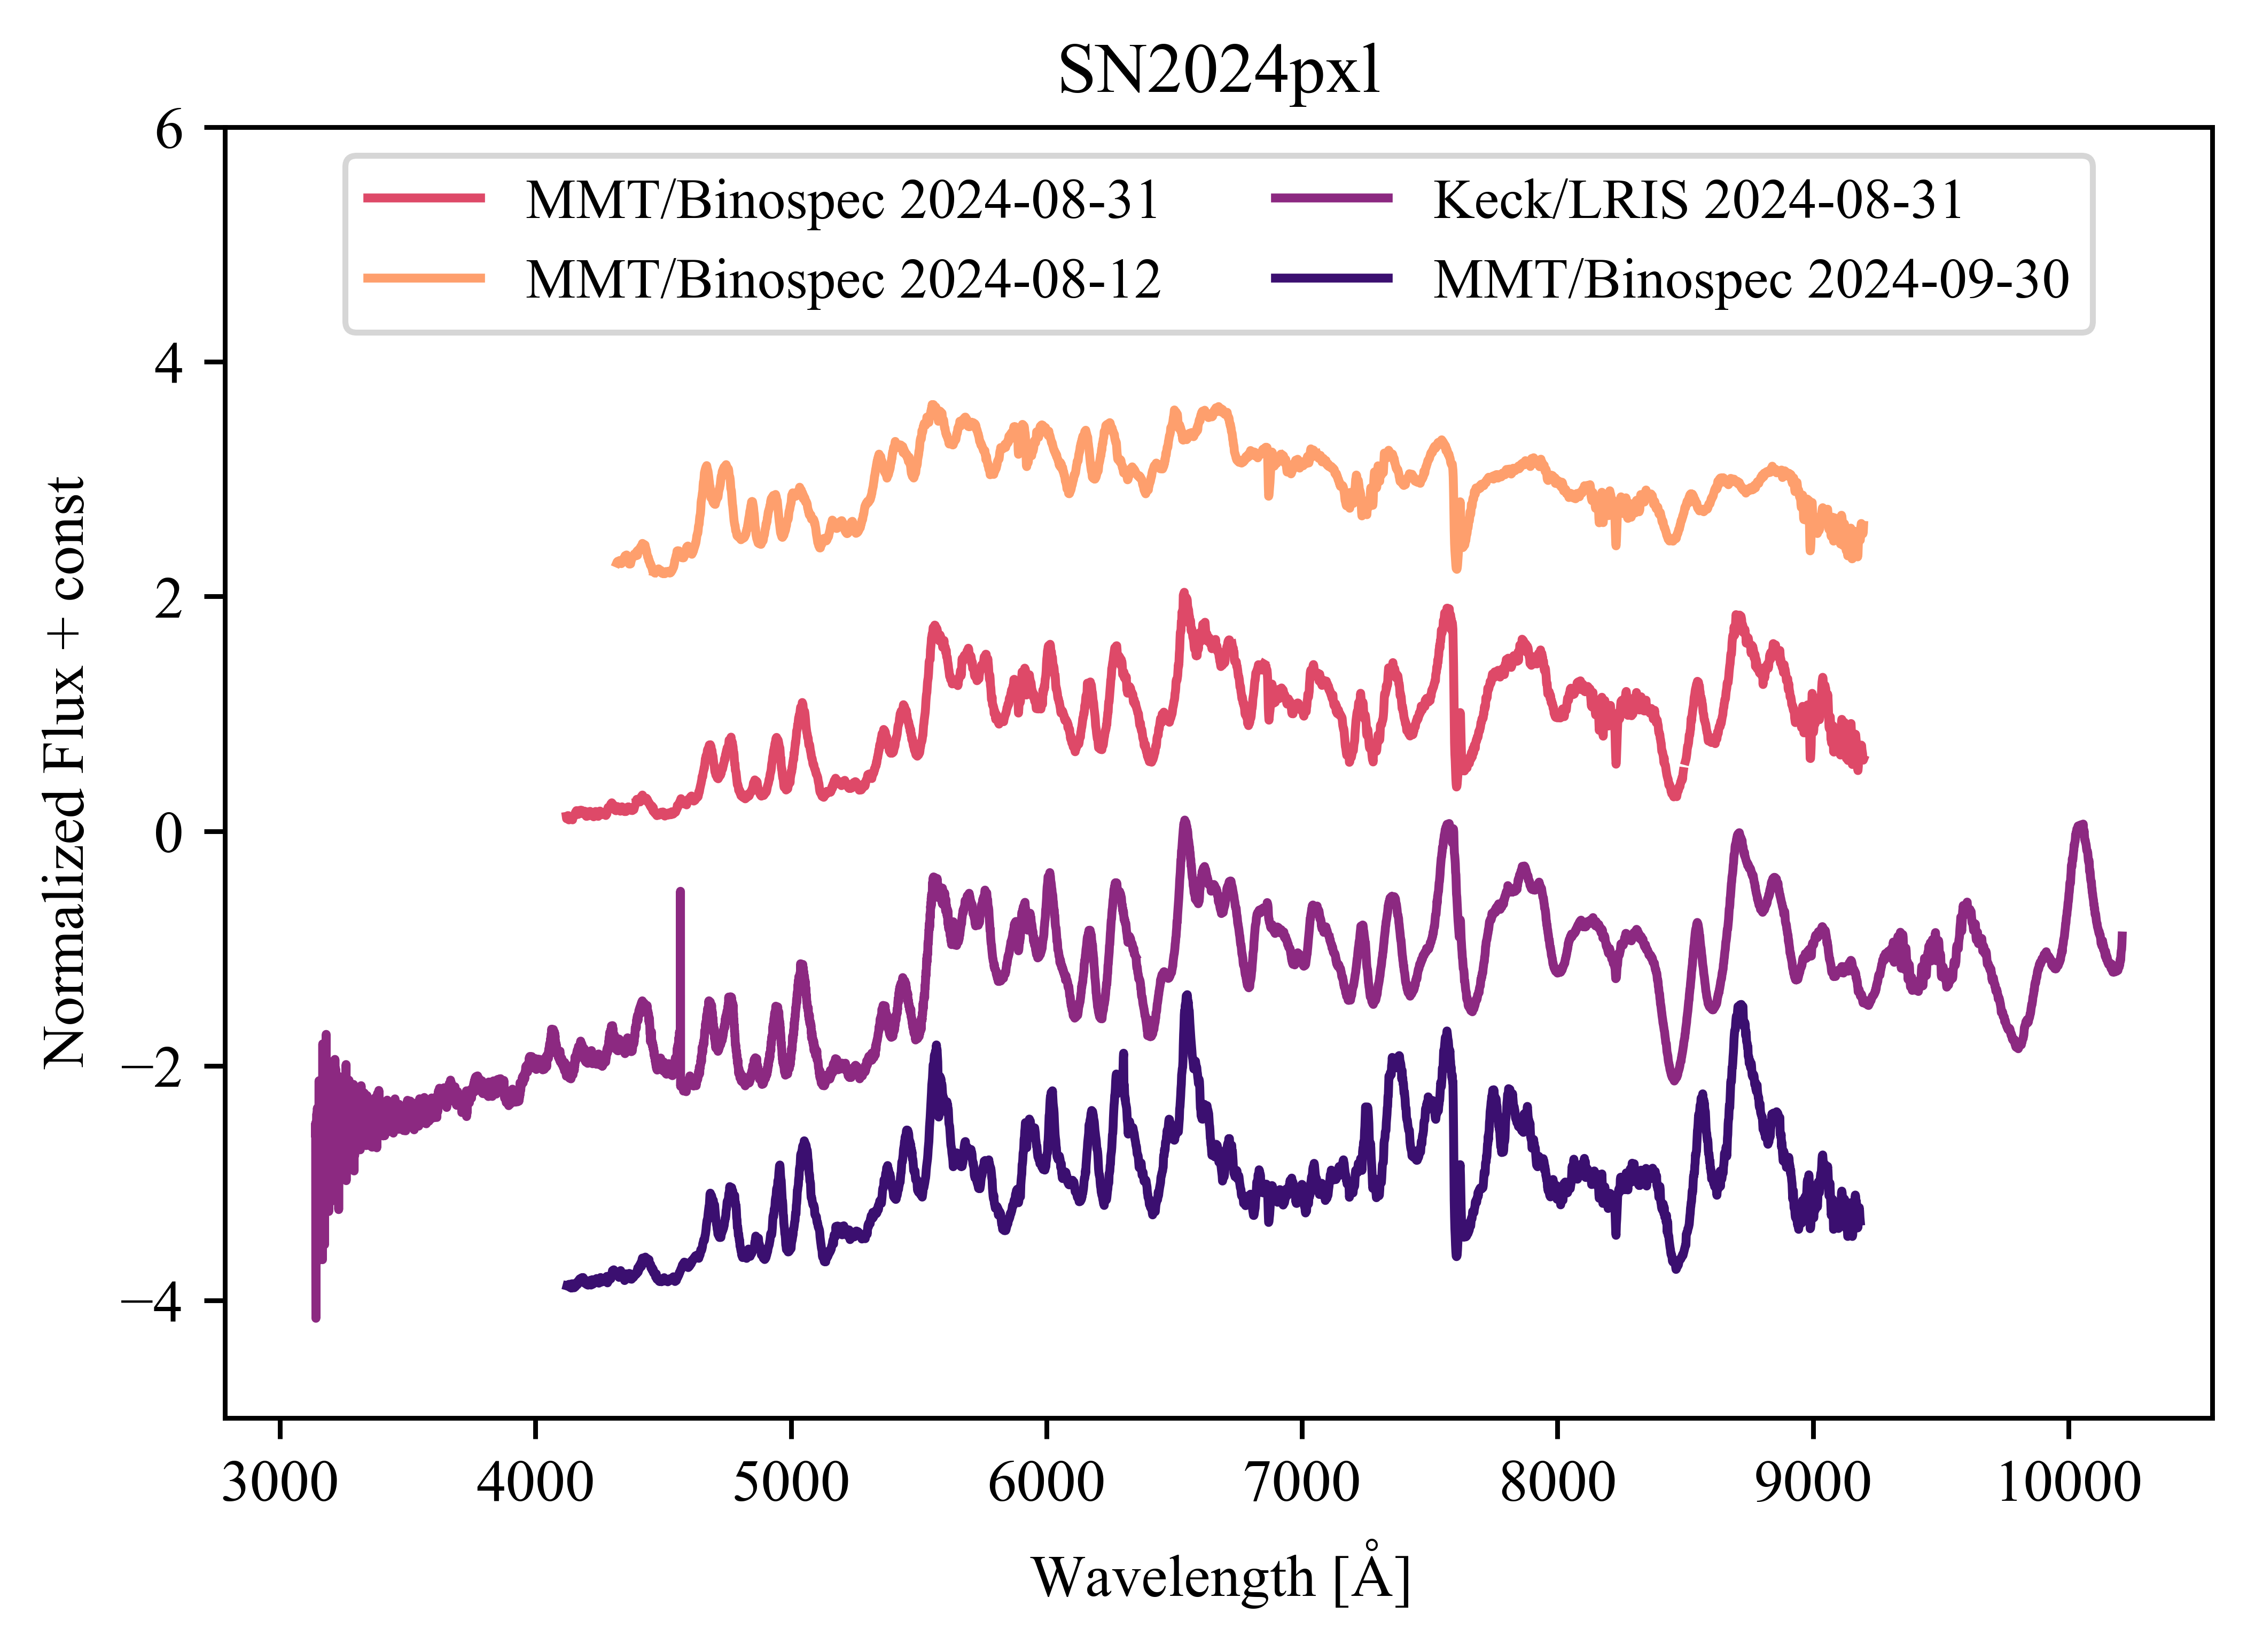

In [42]:
cmap = plt.get_cmap('magma')
plt.set_cmap(cmap)
print(cmap)

plt.title(sn_name)
order = [2,1,3,4]
steps = [0,2,-2.5,-4]
labels = ['MMT/Binospec 2024-08-31', 'MMT/Binospec 2024-08-12', 'Keck/LRIS 2024-08-31', 'MMT/Binospec 2024-09-30']

color_step = 1/(len(spec_pic[0])+1)

for i in range(len(spec_pic[2])):
    plt.plot(spec_pic[0][i],spec_pic[1][i]/np.nanmedian(spec_pic[1][i])+steps[i],label=labels[i], zorder=len(spec_pic[2])-order[i], color=cmap(1-(order[i])*color_step))

#plt.plot(spec_pic[0][1],spec_pic[1][1]/np.nanmedian(spec_pic[1][1])+2, label='MMT/Binospec 2023-12-15', zorder=4, color=cmap(1-2*color_step))

#plt.plot(spec_pic[0][2],spec_pic[1][2]/np.nanmedian(spec_pic[1][2]), label = 'Bok/B&C Spec 2023-12-15', zorder=4, color=cmap(1-3*color_step))

#plt.plot(spec_pic[0][3],spec_pic[1][3]/np.nanmedian(spec_pic[1][3])-2.5, label='MMT/Binospec 2024-01-14', color=cmap(1-4*color_step), zorder=4)
#plt.plot(spec_pic[0][4],spec_pic[1][4]/np.nanmedian(spec_pic[1][4])-4.5, label='Bok/B&C Spec 2024-02-14', color=cmap(1-5*color_step), zorder=4)

#mask = np.isnan(spec_pic[1][5]) ^ True
#plt.plot(spec_pic[0][5][mask],spec_pic[1][5][mask]/np.nanmedian(spec_pic[1][5])-7.5, label='MMT/Binospec 2024-03-02', color=cmap(1-6*color_step), zorder=4)

plt.ylim(-5, 6)
plt.ylabel('Normalized Flux + const')
plt.xlabel(r'Wavelength [$\mathrm{\AA}$]')
plt.legend(ncol=2, loc='upper center', fontsize=9.5)


plt.savefig(dir0 + f'{sn_name}_AZ_spectra_fig.png', bbox_inches = 'tight')

# Mangle to Photometry

In [ ]:
# calibrate spectra to photometry
from lightcurve_fitting.lightcurve import LC
from astropy.table import vstack, Table
from lightcurve_fitting.speccal import calibrate_spectra, readspec

lc_path='/home/jenivevepearson/Downloads/'
lc = LC.read(lc_path+'sn2023emq_unsubtracted_alltels.txt')
print(lc)

lc['nondet']=False
#lc_lco = lc.where(telescope=['Las Cumbres'])
#Table.read()
#print(lc['freq'])

lc.meta['redshift'] = 0.0338
lc.meta['dm'] = 17.5+18.7
lc.meta['ebv'] = 0.105 # Milky Way extinction
lc.meta['host_ebv'] = 0.0  # host galaxy extinction

lc.calcFlux()
lc.calcMag()
lc.calcAbsMag()
lc.plot(xcol='MJD', ycol='flux', offset_factor=0, zorder=1)

In [ ]:
sn_path = dir1+ifile
print(sn_path)
calibrate_spectra([sn_path], lc, show=True, order=2)